# FIFA World Cup Analysis (1930-2022)
## DSM050 Data Visualisation: Midterm Coursework

- **Module:** DSM050 Data Visualisation
- **Dataset:** International Football Results 1872-2026 (Kaggle)
- **Word count target:** 2,000-2,500 words

---


## 1. Research Context and Problem Definition

### 1.1 Domain Overview

The FIFA World Cup is the world's most watched sporting event, held every four years since 1930 and drawing a global television audience of over five billion viewers for its final stages (FIFA, 2023). As both a sporting and cultural institution, it provides a rich longitudinal dataset spanning nearly a century of international football competition.

The tournament has evolved over that period, from 13 teams in Uruguay in 1930 to 32 from 1998 onwards, with a further expansion to 48 teams planned from 2026 (FIFA, 2023). This evolution creates natural analytical questions about how competitive dynamics, goal scoring patterns, and the balance of power between continental confederations have changed across eras.

Sports analytics has emerged as an academic and professional discipline, applying statistical and data visualisation methods to uncover patterns in athletic performance data (Alamar, 2013). Within football specifically, data driven analysis has been applied to player recruitment, tactical preparation, and the evaluation of refereeing decisions (Pappalardo et al., 2019). However, tournament level longitudinal analysis (examining how macro level performance indicators shift across decades) remains a valuable complement to match by match approaches (Lago-Peñas et al., 2010).

The dataset used in this analysis (Martj42, 2024) aggregates results from official international matches since 1872, sourced from Wikipedia, RSSSF, and national football associations. It covers all 22 FIFA World Cup tournaments from 1930 to 2022, comprising 1,061 matches with associated match scores, host country, and venue information. A companion file records individual goalscorer data for 2,720 World Cup goal events.

### 1.2 Research Objectives

This study aims to:

1. Examine how goal scoring volume and match outcome distributions have evolved across World Cup tournaments from 1930 to 2022
2. Identify differences in competitive dynamics between the group stage and knockout rounds
3. Quantify the home nation advantage for World Cup host countries

### 1.3 Target Audience

This analysis targets **sports journalists and the general public** seeking data grounded narratives about the World Cup's history. Visualisations are therefore designed to be interpretable, with explanatory titles and minimal technical jargon. The dashboard is structured as an at a glance summary a journalist could use to support a feature article.


## 2. Research Questions and Literature Support

Prior research on football analytics has established that tournament level data can reveal systematic patterns that are not visible in single match analyses. Lago-Peñas et al. (2010) demonstrated that match context (including scoreline, game stage, and opponent strength) significantly influences tactical and performance metrics. At the tournament level, Pappalardo et al. (2019) showed that team performance in group stages is predictive of knockout progression, suggesting that stage level segmentation is analytically useful.

**RQ1: How has goal scoring volume and match outcome distribution evolved across World Cup tournaments from 1930 to 2022?**

Goal scoring trends in international football are influenced by tactical evolution, changes in tournament format, and shifts in team ability distributions (Pollard & Reep, 1997). Understanding long run trends in goals per match provides context for debates about whether modern football has become more or less attacking. The inclusion of tournament format changes (e.g. the 1998 expansion to 32 teams) allows for era controlled comparisons.

**RQ2: How do goal scoring patterns and decisive vs drawn results differ between group stage and knockout rounds?**

The incentive structure of group stage football differs fundamentally from knockout rounds. A draw is sometimes a strategically acceptable result in the group stage, whereas knockout rounds impose a decisive outcome (Colomer et al., 2021). This difference in incentive design is expected to produce measurable differences in goal counts, draw rates, and match outcome distributions. Visualising these differences helps general audiences understand the structural dynamics of the tournament format.

**RQ3: Does hosting the World Cup provide a measurable advantage in match outcomes and goal difference for the host nation?**

The home advantage in football is well documented at club level (Pollard, 2006), but the evidence at international tournament level is more nuanced. Host nations play in familiar conditions, in front of home crowds, and with lesser disruption of travel, which may confer a competitive advantage. Examining host performance across 22 tournaments provides a longitudinal test of this hypothesis.


## 3. Dataset Manipulation and Preprocessing

In [ ]:
# 3.0 pip installs
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install plotly
%pip install nbformat
%pip install kaleido

In [2]:
#  3.1 Imports and config
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

#  Colot palletes to use (inspired from adobe color pallete generator page: https://color.adobe.com/create/color-wheel) 
# Categorical slots 1-6 (light mode)
C1 = '#2a78d6'   # blue
C2 = '#1baf7a'   # aqua
C3 = '#eda100'   # yellow
C4 = '#008300'   # green
C5 = '#4a3aa7'   # violet
C6 = '#e34948'   # red
MUTED     = '#898781'
GRIDLINE  = '#e1e0d9'
SURFACE   = '#fcfcfb'
INK       = '#0b0b0b'
INK_SEC   = '#52514e'

# Matplotlib global style
plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor':   SURFACE,
    'axes.edgecolor':   GRIDLINE,
    'axes.labelcolor':  INK_SEC,
    'axes.grid':        True,
    'grid.color':       GRIDLINE,
    'grid.linewidth':   0.8,
    'grid.linestyle':   '-',
    'xtick.color':      MUTED,
    'ytick.color':      MUTED,
    'text.color':       INK,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.titlepad':    10,
    'figure.dpi':       150,
    'savefig.dpi':      150,
    'savefig.bbox':     'tight',
    'savefig.facecolor': SURFACE,
})
# Note that the directory below is the directory where I unzipped files. Rename it to the folder name where you have unzipped the files. 
# The folder should contain the following files: results.csv, goalscorers.csv, and WorldCupMatches.csv
# Note that the notebook should be in the same parent directory. Data files provided in the git repo. 
# Originally obtained from https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017
DATA_DIR = 'International football results from 1872 to 2026'
print('Libraries loaded. Palette configured.')


Libraries loaded. Palette configured.


### 3.1 Data Loading and Initial Inspection

The dataset comprises four CSV files. For this analysis, `results.csv` (match results) and `goalscorers.csv` (individual goal events) are the primary sources. The `shootouts.csv` and `former_names.csv` files are not used, as the research questions focus on match level outcomes and goal counts rather than penalty shootout details or historical team name reconciliation.


In [3]:
#  3.2 Load raw data 
results_raw   = pd.read_csv(f'{DATA_DIR}/results.csv')
goalscorers_raw = pd.read_csv(f'{DATA_DIR}/goalscorers.csv')

print('results.csv  shape:', results_raw.shape)
print('goalscorers.csv shape:', goalscorers_raw.shape)
print()
print(results_raw.dtypes)
print()
print('Missing values:')
print(results_raw.isnull().sum())


results.csv  shape: (49502, 9)
goalscorers.csv shape: (47867, 8)

date              str
home_team         str
away_team         str
home_score    float64
away_score    float64
tournament        str
city              str
country           str
neutral          bool
dtype: object

Missing values:
date          0
home_team     0
away_team     0
home_score    7
away_score    7
tournament    0
city          0
country       0
neutral       0
dtype: int64


In [4]:
# Quick overview of structure and distributions before filtering
display(results_raw.head())
display(results_raw.describe(include='all').T)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,49502,16481,2012-02-29,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_team,49502,327,Brazil,618,NaN,NaN,NaN,NaN,NaN,NaN,NaN
away_team,49502,321,Uruguay,585,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_score,49495.0,NaN,NaN,NaN,1.757268,1.773877,0.0,1.0,1.0,2.0,31.0
away_score,49495.0,NaN,NaN,NaN,1.181837,1.401639,0.0,0.0,1.0,2.0,21.0
tournament,49502,200,Friendly,18388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,49502,2089,Kuala Lumpur,745,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,49502,269,United States,1578,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neutral,49502,2,False,36360,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#  3.3 Filter to FIFA World Cup tournament matches only 
# The dataset contains 49,502 matches across many tournament types.
# We retain only rows where tournament == 'FIFA World Cup', which gives us the
# 1,061 matches from the 22 tournaments (1930–2022).
# 'FIFA World Cup qualification' matches are excluded. They are a separate
# competition with different competitive dynamics and are not relevant to RQs 1–3.

wc = results_raw[results_raw['tournament'] == 'FIFA World Cup'].copy()
wc['date'] = pd.to_datetime(wc['date'])
wc['year']  = wc['date'].dt.year

# Exclude 2026, the tournament was still in progress at the time of this analysis.
wc = wc[wc['year'] <= 2022].copy()

print(f'World Cup matches (1930–2022): {len(wc)}')
print(f'Tournaments: {sorted(wc["year"].unique())}')


World Cup matches (1930–2022): 964
Tournaments: [np.int32(1930), np.int32(1934), np.int32(1938), np.int32(1950), np.int32(1954), np.int32(1958), np.int32(1962), np.int32(1966), np.int32(1970), np.int32(1974), np.int32(1978), np.int32(1982), np.int32(1986), np.int32(1990), np.int32(1994), np.int32(1998), np.int32(2002), np.int32(2006), np.int32(2010), np.int32(2014), np.int32(2018), np.int32(2022)]


### 3.2 Handling Missing Values

The raw dataset contains 7 rows with null values in `home_score` or `away_score`. As we will see below, these were all filtered out when filtering by the `year <= 2022` filter in the previous step. Thus when the null check runs below, zero nulls remain. A `dropna` call is retained as a defensive guard in case the dataset is updated with new partially-recorded matches.


In [6]:
#  3.4 Handle missing values 
missing_before = wc[['home_score', 'away_score']].isnull().sum()
print('Missing before:', missing_before.to_dict())

wc = wc.dropna(subset=['home_score', 'away_score']).copy()
wc['home_score'] = wc['home_score'].astype(int)
wc['away_score'] = wc['away_score'].astype(int)

print(f'Rows after dropping nulls: {len(wc)}')
print('Missing after:', wc[['home_score','away_score']].isnull().sum().to_dict())


Missing before: {'home_score': 0, 'away_score': 0}
Rows after dropping nulls: 964
Missing after: {'home_score': 0, 'away_score': 0}


### 3.3 Derived Columns

Several derived variables are created to support the analysis:

- **`total_goals`**: sum of home and away goals. Used directly in RQ1 and RQ2 distributions. Created rather than computed inline so that the derivation is explicit and traceable.
- **`goal_diff`**: absolute goal difference (|home − away|). A measure of match decisiveness used in RQ3.
- **`outcome`**: categorical match result coded as Decisive or Draw. Since 87% of World Cup matches are played on neutral ground (only host nation matches have a genuine home team), a home/away split based on the dataset's positional team labelling would be analytically misleading. The outcome therefore flags whether a match produced a winner (Decisive) or not (Draw). This variable is used in RQ1 era comparisons and RQ2 stage comparisons.
- **`stage`**: derived by sorting matches chronologically within each tournament year and assigning stages by counting backwards from the end. The Final is always the last match of the year; stage boundaries (Semi final, Quarter final, Round of 16, Group Stage) are then set based on the known total match count for each tournament format. This approach is necessary because the source dataset has no stage column. A plain per year loop is used rather than `groupby().apply()` to avoid a known pandas 3.x issue where the groupby key column is dropped from the returned DataFrame, causing index misalignment on concatenation.
- **`era`**: tournament year bucketed into three historical eras to support trend analysis in RQ1.
- **`is_host_match`**: boolean flag identifying whether the host nation of that tournament was playing. Derived by mapping the host country (from the `country` column) to the teams in that match. The `country` column records the physical location of each match, which equals the host nation for all World Cup matches.


In [ ]:
#  3.5 Derive analytical columns 
wc['total_goals'] = wc['home_score'] + wc['away_score']
wc['goal_diff']   = (wc['home_score'] - wc['away_score']).abs()

# Outcome: Decisive (a winner) or Draw.
# home/away labels in the source data are positional, not meaningful for neutral matches.
# 87% of WC matches are neutral, so Decisive/Draw is the analytically valid encoding.
def get_outcome(row):
    if row['home_score'] == row['away_score']:
        return 'Draw'
    else:
        return 'Decisive'

wc['outcome'] = wc.apply(get_outcome, axis=1)

#  Stage derivation 
# The source dataset has no stage column. Stages are reconstructed by sorting
# matches by date within each year and counting backwards from the end:
# the Final is always last, and the stage boundaries vary by total match count
# (which encodes the known tournament format for that year).
# Known WC formats by total match count:
#   <=26 matches (1930-1954): knockout-heavy, no clean group/KO split by date
#   32-35 matches (1958-1970): 4 groups + QF/SF/Final
#   38 matches (1974-1978): 2nd group round instead of KO
#   52 matches (1982-1994): 6 groups + R16 + QF/SF/Final
#   64 matches (1998-2022): 8 groups (48) + R16(8) + QF(4) + SF(2) + 3rd+Final(2)

def assign_stages_for_year(df_year):
    df_year = df_year.sort_values('date').copy()
    n = len(df_year)
    stages = []
    for rank in range(n):
        rev = n - 1 - rank   # 0 = Final, 1 = penultimate, ...
        if n >= 52:
            if rev < 2:
                s = 'Final / 3rd Place'
            elif rev < 4:
                s = 'Semi-final'
            elif rev < 8:
                s = 'Quarter-final'
            elif rev < 16:
                s = 'Round of 16'
            else:
                s = 'Group Stage'
        elif n >= 38:
            if rev < 2:
                s = 'Final / 3rd Place'
            elif rev < 4:
                s = 'Semi-final'
            elif rev < 10:
                s = 'Second Group Round'
            else:
                s = 'Group Stage'
        elif n >= 32:
            if rev < 2:
                s = 'Final / 3rd Place'
            elif rev < 4:
                s = 'Semi-final'
            elif rev < 8:
                s = 'Quarter-final'
            else:
                s = 'Group Stage'
        else:
            if rev < 2:
                s = 'Final / 3rd Place'
            elif rev < 4:
                s = 'Semi-final'
            elif rev < 8:
                s = 'Quarter-final'
            else:
                s = 'Group Stage'
        stages.append(s)
    df_year['stage'] = stages
    return df_year

# Plain loop rather than groupby().apply(). pandas 3.x drops the groupby key column
# from the returned DataFrame, causing index misalignment when concatenating results.
parts = []
for yr, grp in wc.groupby('year'):
    parts.append(assign_stages_for_year(grp))
wc = pd.concat(parts).sort_values('date').reset_index(drop=True)

# Ordinal ordering for stage
STAGE_ORDER = ['Group Stage', 'Second Group Round', 'Round of 16',
               'Quarter-final', 'Semi-final', 'Final / 3rd Place']
wc['stage'] = pd.Categorical(wc['stage'], categories=STAGE_ORDER, ordered=True)

#  Era bucketing 
def get_era(y):
    if y <= 1966:
        return '1930-1966 (Pre-modern)'
    elif y <= 1990:
        return '1970-1990 (Expansion era)'
    else:
        return '1994-2022 (Modern era)'

wc['era'] = wc['year'].apply(get_era)

#  Host team flag 
# country = physical location of match = tournament host for all WC matches
# neutral=False in the source data identifies the 121 matches where the host nation is playing.
# is_host_match replicates this using team names so the flag survives after neutral is dropped.
host_map = wc.groupby('year')['country'].agg(lambda x: x.value_counts().index[0])
wc['host_nation'] = wc['year'].map(host_map)

# Special case: 2002 co-hosted by South Korea AND Japan
wc.loc[wc['year'] == 2002, 'host_nation'] = 'Korea/Japan'

def is_host_match(row):
    h = row['host_nation']
    if h == 'Korea/Japan':
        return row['home_team'] in ['South Korea', 'Japan'] or \
               row['away_team'] in ['South Korea', 'Japan']
    return row['home_team'] == h or row['away_team'] == h

wc['is_host_match'] = wc.apply(is_host_match, axis=1)

# Verify is_host_match aligns with the source neutral column
assert wc['is_host_match'].sum() == (wc['neutral'] == False).sum(), \
    "is_host_match count does not match neutral=False count - check host derivation logic"

print('Derived columns created.')
print(f'Host nation matches: {wc["is_host_match"].sum()} (matches neutral=False: {(wc["neutral"]==False).sum()})')
display(wc[['year','home_team','away_team','total_goals','outcome','stage','era','is_host_match']].head(8))


Derived columns created.
Host nation matches: 121 (matches neutral=False: 121)


,year,home_team,away_team,total_goals,outcome,stage,era,is_host_match
0,1930,Belgium,United States,3,Decisive,Group Stage,1930-1966 (Pre-modern),False
1,1930,France,Mexico,5,Decisive,Group Stage,1930-1966 (Pre-modern),False
2,1930,Brazil,Yugoslavia,3,Decisive,Group Stage,1930-1966 (Pre-modern),False
3,1930,Peru,Romania,4,Decisive,Group Stage,1930-1966 (Pre-modern),False
4,1930,Argentina,France,1,Decisive,Group Stage,1930-1966 (Pre-modern),False
5,1930,Chile,Mexico,3,Decisive,Group Stage,1930-1966 (Pre-modern),False
6,1930,Bolivia,Yugoslavia,4,Decisive,Group Stage,1930-1966 (Pre-modern),False
7,1930,Paraguay,United States,3,Decisive,Group Stage,1930-1966 (Pre-modern),False


### 3.4 Dimensionality Reduction

Several columns from the original dataset are not relevant to the research questions and are excluded from further analysis:

- **`city`**: the specific city where matches were played. City level variation is not necessary for any of the three research questions and would add noise to groupings.
- **`neutral`**: a boolean indicating whether the match was at a neutral venue. In the World Cup context, all matches except those involving the host nation are played at a neutral venue (the host country's stadiums), making this column partially redundant with the `is_host_match` derived column. Verification confirms `neutral == False` aligns exactly with `is_host_match == True` across all 121 host nation matches.
- **`tournament`**: all remaining rows have `tournament == 'FIFA World Cup'` after filtering, so this column carries no variance and no analytical value.

The retained analytical columns are: `date`, `year`, `home_team`, `away_team`, `home_score`, `away_score`, `country`, `total_goals`, `goal_diff`, `outcome`, `stage`, `era`, `is_host_match`, `host_nation`.

The goalscorer data (`goalscorers.csv`) is filtered to World Cup matches by joining on date and teams, producing 2,720 goal events used for supplementary analysis in Section 4.


In [8]:
#  3.6 Drop irrelevant columns 
cols_drop = ['city', 'neutral', 'tournament']
wc_clean = wc.drop(columns=cols_drop)

print('Final dataset shape:', wc_clean.shape)
print('Columns retained:', list(wc_clean.columns))
print()
print('Summary statistics:')
print(wc_clean[['total_goals','goal_diff','home_score','away_score']].describe().round(2))


Final dataset shape: (964, 14)
Columns retained: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'country', 'year', 'total_goals', 'goal_diff', 'outcome', 'stage', 'era', 'host_nation', 'is_host_match']

Summary statistics:
       total_goals  goal_diff  home_score  away_score
count       964.00     964.00      964.00      964.00
mean          2.82       1.49        1.57        1.25
std           1.93       1.41        1.49        1.30
min           0.00       0.00        0.00        0.00
25%           1.00       1.00        0.00        0.00
50%           3.00       1.00        1.00        1.00
75%           4.00       2.00        2.00        2.00
max          12.00       9.00       10.00        8.00


In [9]:
#  3.7 Goalscorer data 
# Filter goalscorers to World Cup matches only (join on date + teams)
gs = goalscorers_raw.copy()
gs['date'] = pd.to_datetime(gs['date'])

wc_keys = wc_clean[['date','home_team','away_team']].drop_duplicates()
wc_goals = gs.merge(wc_keys, on=['date','home_team','away_team'])
wc_goals = wc_goals.merge(wc_clean[['date','home_team','away_team','year','stage','era']],
                           on=['date','home_team','away_team'])

print(f'World Cup goal events: {len(wc_goals)}')
print(wc_goals.dtypes)
print()
print('Own goals:', wc_goals['own_goal'].sum())
print('Penalties:', wc_goals['penalty'].sum())


World Cup goal events: 2720
date         datetime64[us]
home_team               str
away_team               str
team                    str
scorer                  str
minute              float64
own_goal               bool
penalty                bool
year                  int32
stage              category
era                     str
dtype: object

Own goals: 54
Penalties: 214


## 4. Exploratory Data Analysis (EDA) and Visualisation

### 4.1 Univariate Analysis

Before examining relationships between variables, each key variable is described on its own. A bar chart is used for the nominal outcome variable because it directly encodes frequency as bar length, making relative proportions readable for a general audience. An ordered bar chart is used for tournament stage because the ordinal progression (Group Stage through Final) is the natural reading order and must be preserved visually. A histogram is used for total goals per match because it reveals the shape of a continuous distribution (whether the data is symmetric, skewed, or multimodal) that a single summary statistic cannot convey. Mean and median are annotated directly on the histogram rather than using a secondary y axis, consistent with best practice (Kelleher and Wagener, 2011).


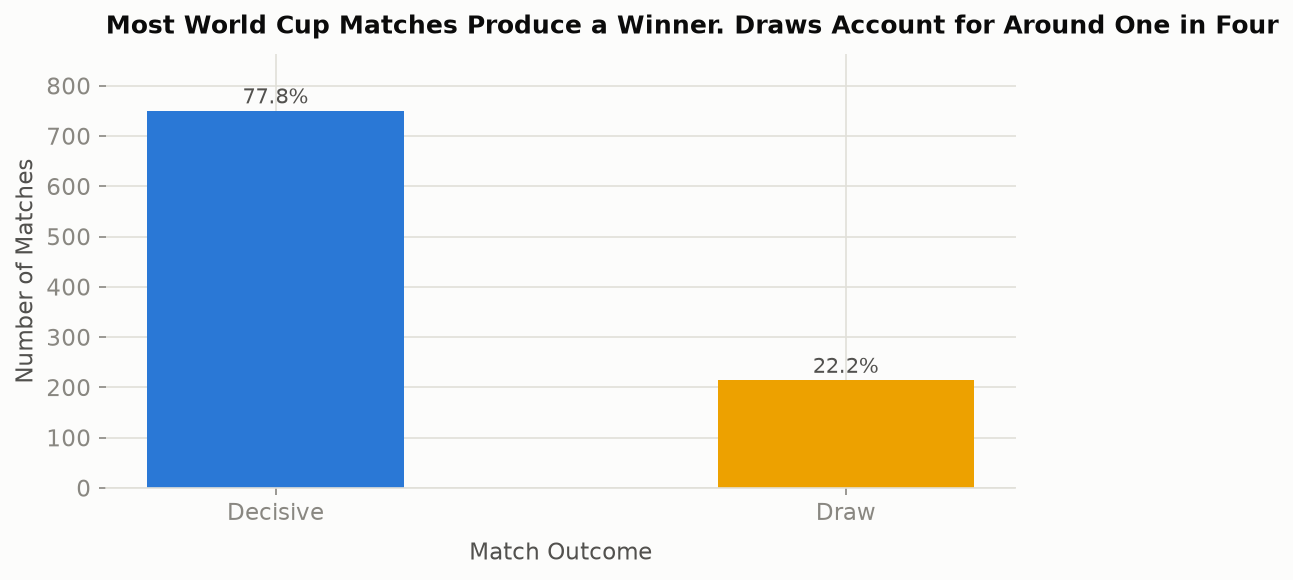

Figure 1 saved.
outcome
Decisive    750
Draw        214
Name: count, dtype: int64


In [10]:
#  Figure 1: Univariate - Nominal: Match Outcome Distribution 
outcome_counts = wc_clean['outcome'].value_counts()
outcome_pct    = (outcome_counts / len(wc_clean) * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = [C1 if o == 'Decisive' else C3 for o in outcome_counts.index]
bars = ax.bar(outcome_counts.index, outcome_counts.values,
              color=bar_colors, width=0.45, linewidth=0)

for bar, pct in zip(bars, outcome_pct):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f'{pct}%', ha='center', va='bottom',
            fontsize=10, color=INK_SEC)

ax.set_title('Most World Cup Matches Produce a Winner. Draws Account for Around One in Four',
             loc='left')
ax.set_xlabel('Match Outcome', labelpad=8)
ax.set_ylabel('Number of Matches')
ax.set_ylim(0, outcome_counts.max() * 1.15)
ax.yaxis.grid(True, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_outcome_distribution.png')
plt.show()
print('Figure 1 saved.')
print(outcome_counts)


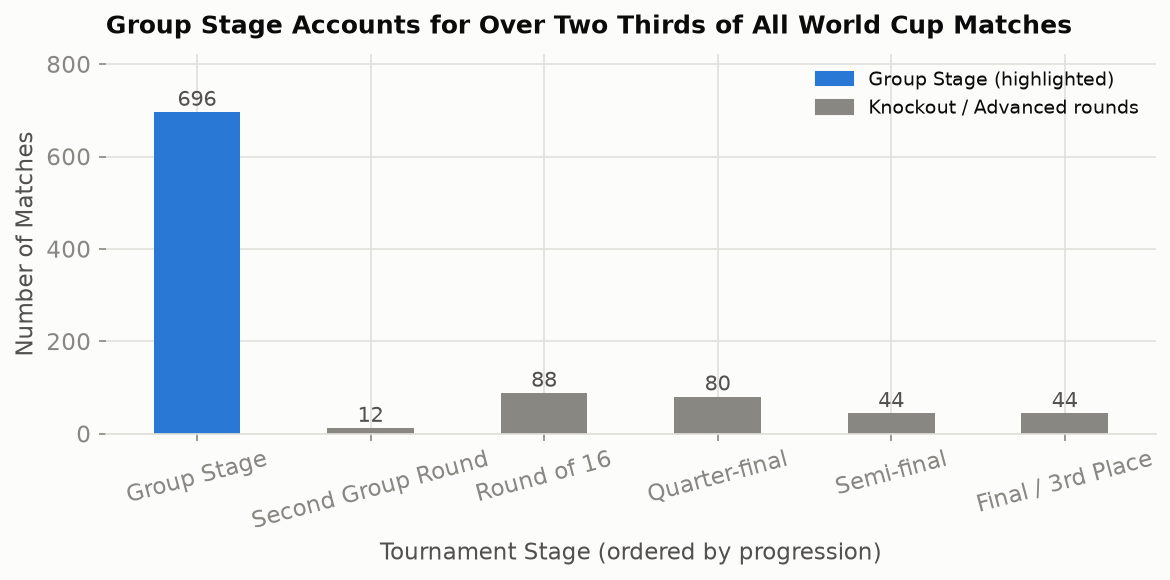

Figure 2 saved.


In [11]:
#  Figure 2: Univariate - Ordinal: Match Count by Tournament Stage 
stage_counts = wc_clean['stage'].value_counts().reindex(STAGE_ORDER)

fig, ax = plt.subplots(figsize=(8, 4))
colors_ord = [C1 if s == 'Group Stage' else MUTED for s in stage_counts.index]
bars = ax.bar(stage_counts.index, stage_counts.values,
              color=colors_ord, width=0.5, linewidth=0)

for bar, val in zip(bars, stage_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            str(val), ha='center', va='bottom',
            fontsize=10, color=INK_SEC)

ax.set_title('Group Stage Accounts for Over Two Thirds of All World Cup Matches',
             loc='left')
ax.set_xlabel('Tournament Stage (ordered by progression)')
ax.set_ylabel('Number of Matches')
ax.tick_params(axis='x', rotation=15)
ax.set_ylim(0, stage_counts.max() * 1.18)
ax.yaxis.grid(True, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[['top','right','left']].set_visible(False)

patch_gs  = mpatches.Patch(color=C1, label='Group Stage (highlighted)')
patch_ko  = mpatches.Patch(color=MUTED, label='Knockout / Advanced rounds')
ax.legend(handles=[patch_gs, patch_ko], frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('fig2_stage_distribution.png')
plt.show()
print('Figure 2 saved.')


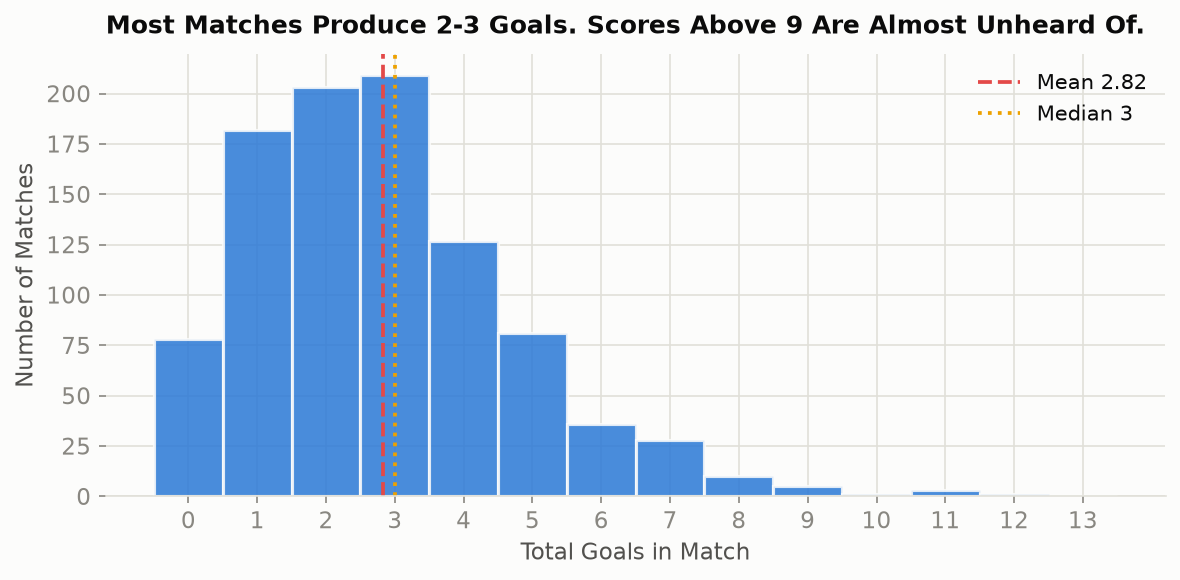

Figure 3 saved. Mean goals/match: 2.82, Median: 3.0


In [12]:
#  Figure 3: Univariate - Numerical: Goals per Match Distribution 
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(wc_clean['total_goals'], bins=range(0, 15),
        color=C1, alpha=0.85, edgecolor=SURFACE, linewidth=1.5,
        density=False, align='left')

mean_g = wc_clean['total_goals'].mean()
med_g  = wc_clean['total_goals'].median()

ax.axvline(mean_g, color=C6, linewidth=1.8, linestyle='--', label=f'Mean {mean_g:.2f}')
ax.axvline(med_g,  color=C3, linewidth=1.8, linestyle=':',  label=f'Median {med_g:.0f}')

ax.set_title('Most Matches Produce 2-3 Goals. Scores Above 9 Are Almost Unheard Of.',
             loc='left')
ax.set_xlabel('Total Goals in Match')
ax.set_ylabel('Number of Matches')
ax.set_xticks(range(0, 14))
ax.yaxis.grid(True, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[['top','right','left']].set_visible(False)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('fig3_goals_histogram.png')
plt.show()
print(f'Figure 3 saved. Mean goals/match: {mean_g:.2f}, Median: {med_g:.1f}')


### 4.2 RQ1: Goal-Scoring Evolution Across Tournaments (1930-2022)

To answer RQ1, a line chart shows the temporal trend in average goals per match across all 22 tournaments. A line chart is the appropriate form for a continuous ordered temporal variable (Qin et al., 2020). The connected markers make the trend and year on year variation visible, and the era shading provides contextual segmentation without requiring a separate chart. The stacked bar chart beneath it shows the Decisive vs Draw split by era. Since 87% of World Cup matches are played on neutral ground, the outcome variable is coded as Decisive or Draw rather than a positional home/away split.


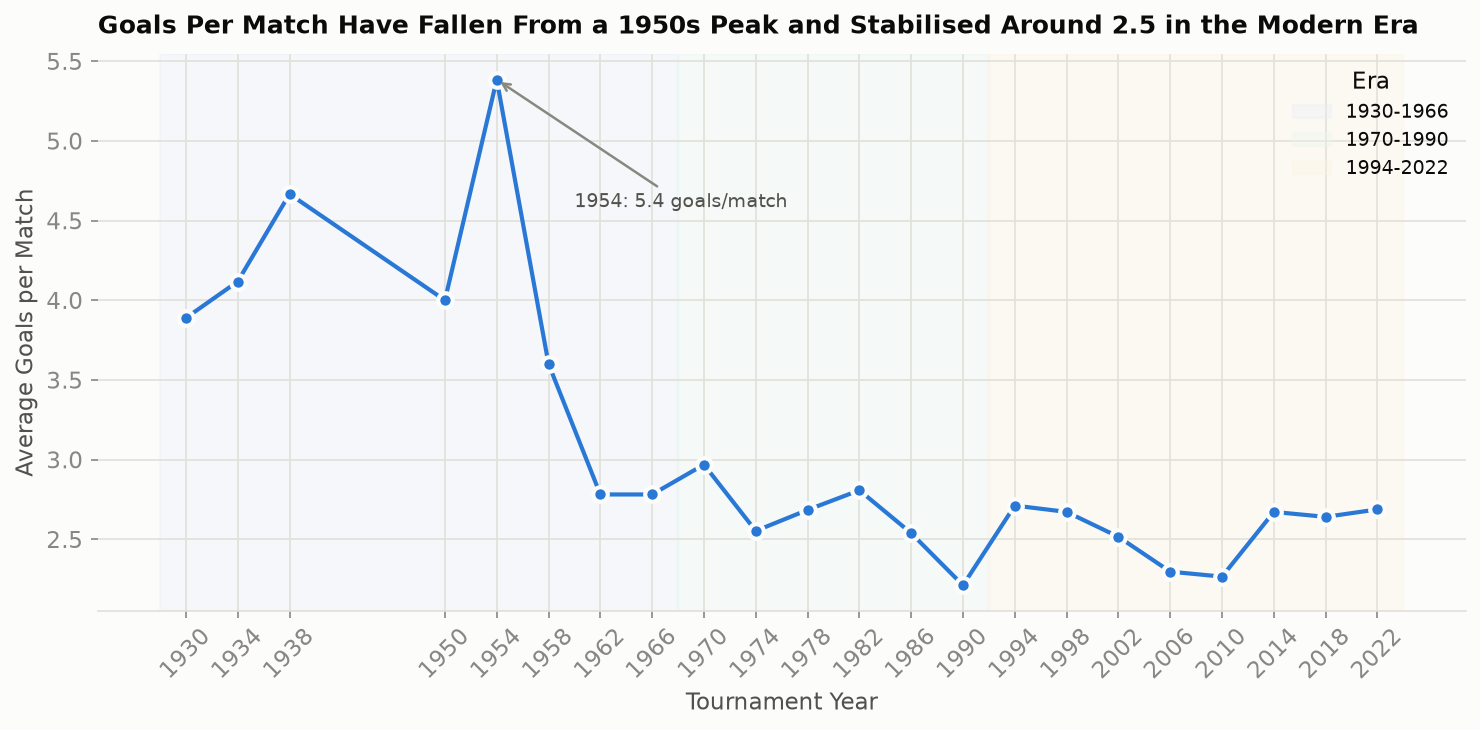

Figure 4 saved.
 year  avg_goals  n_matches
 1930   3.888889         18
 1934   4.117647         17
 1938   4.666667         18
 1950   4.000000         22
 1954   5.384615         26
 1958   3.600000         35
 1962   2.781250         32
 1966   2.781250         32
 1970   2.968750         32
 1974   2.552632         38
 1978   2.684211         38
 1982   2.807692         52
 1986   2.538462         52
 1990   2.211538         52
 1994   2.711538         52
 1998   2.671875         64
 2002   2.515625         64
 2006   2.296875         64
 2010   2.265625         64
 2014   2.671875         64
 2018   2.640625         64
 2022   2.687500         64


In [13]:
#  Figure 4: Average goals per match by year 
yearly = wc_clean.groupby('year').agg(
    avg_goals = ('total_goals', 'mean'),
    n_matches = ('total_goals', 'count'),
    pct_draws = ('outcome', lambda x: (x == 'Draw').mean() * 100),
    pct_hw    = ('outcome', lambda x: (x == 'Home Win').mean() * 100),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(yearly['year'], yearly['avg_goals'],
        color=C1, linewidth=2, marker='o', markersize=7,
        markerfacecolor=C1, markeredgecolor=SURFACE, markeredgewidth=2)

era_bands  = [(1930, 1966, '1930-1966'), (1970, 1990, '1970-1990'), (1994, 2022, '1994-2022')]
era_colors = ['#e8f0fa', '#eaf6f0', '#fdf4e3']
for (s, e, lbl), ec in zip(era_bands, era_colors):
    ax.axvspan(s - 2, e + 2, alpha=0.35, color=ec, zorder=0, label=lbl)

peak_row = yearly.loc[yearly['avg_goals'].idxmax()]
ax.annotate(
    f"1954: {peak_row['avg_goals']:.1f} goals/match",
    xy=(peak_row['year'], peak_row['avg_goals']),
    xytext=(1960, peak_row['avg_goals'] - 0.8),
    fontsize=9, color=INK_SEC,
    arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.2)
)

ax.set_title('Goals Per Match Have Fallen From a 1950s Peak and Stabilised Around 2.5 in the Modern Era',
             loc='left')
ax.set_xlabel('Tournament Year')
ax.set_ylabel('Average Goals per Match')
ax.set_xticks(yearly['year'])
ax.tick_params(axis='x', rotation=45)
ax.yaxis.grid(True, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[['top','right','left']].set_visible(False)
ax.legend(title='Era', frameon=False, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('fig4_goals_by_year.png')
plt.show()
print('Figure 4 saved.')
print(yearly[['year','avg_goals','n_matches']].to_string(index=False))


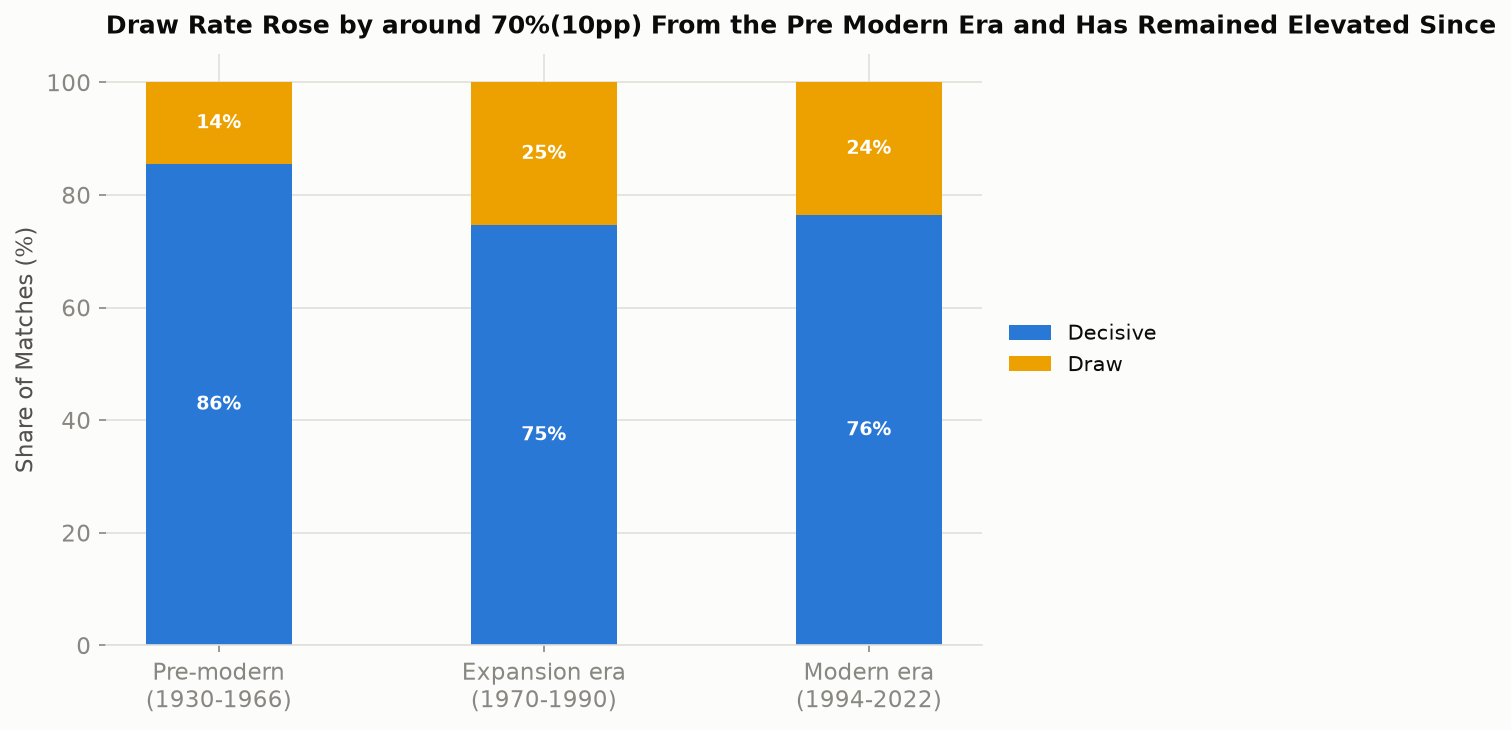

Figure 5 saved.
outcome                    Decisive  Draw
era                                      
1930-1966 (Pre-modern)         85.5  14.5
1970-1990 (Expansion era)      74.6  25.4
1994-2022 (Modern era)         76.4  23.6


In [14]:
#  Figure 5: Match outcome (Decisive vs Draw) by era 
era_outcome = (wc_clean.groupby(['era','outcome'])
                        .size()
                        .unstack(fill_value=0))

era_outcome_pct = era_outcome.div(era_outcome.sum(axis=1), axis=0) * 100

era_order = ['1930-1966 (Pre-modern)', '1970-1990 (Expansion era)', '1994-2022 (Modern era)']
era_outcome_pct = era_outcome_pct.reindex(era_order)

era_labels = ['Pre-modern\n(1930-1966)', 'Expansion era\n(1970-1990)', 'Modern era\n(1994-2022)']
outcome_cols = ['Decisive', 'Draw']
oc_colors    = [C1, C3]

fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(era_order))

for col, clr in zip(outcome_cols, oc_colors):
    vals = era_outcome_pct[col].values if col in era_outcome_pct.columns else np.zeros(3)
    bars = ax.bar(era_labels, vals, bottom=bottom,
                  color=clr, width=0.45, linewidth=0,
                  label=col)
    for b, v, bot in zip(bars, vals, bottom):
        if v > 7:
            ax.text(b.get_x() + b.get_width() / 2,
                    bot + v / 2,
                    f'{v:.0f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += vals

ax.set_title('Draw Rate Rose by around 70%(10pp) From the Pre Modern Era and Has Remained Elevated Since',
             loc='left')
ax.set_ylabel('Share of Matches (%)')
ax.set_ylim(0, 105)
ax.yaxis.grid(True, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[['top','right','left']].set_visible(False)
ax.legend(frameon=False, fontsize=10, loc='center left', bbox_to_anchor=(1.01, 0.5))

plt.tight_layout()
plt.savefig('fig5_outcome_by_era.png')
plt.show()
print('Figure 5 saved.')
print(era_outcome_pct.round(1))


### 4.3 RQ2: Group Stage vs Knockout Round Patterns

RQ2 requires comparing a numerical variable (goals per match) and a categorical variable (match outcome) across two stage groups. A box plot is selected for the goals comparison because it shows the median, spread, and outliers in one view, more useful than a bar of means when the data has a long tail, as goal counts do. A grouped bar chart is used for the outcome comparison, showing Decisive vs Draw rates for each stage type, because it enables direct percentage comparisons between the two groups. The correlation heatmap uses a diverging blue red palette centred on zero, which encodes polarity (positive vs negative correlation) as well as magnitude.


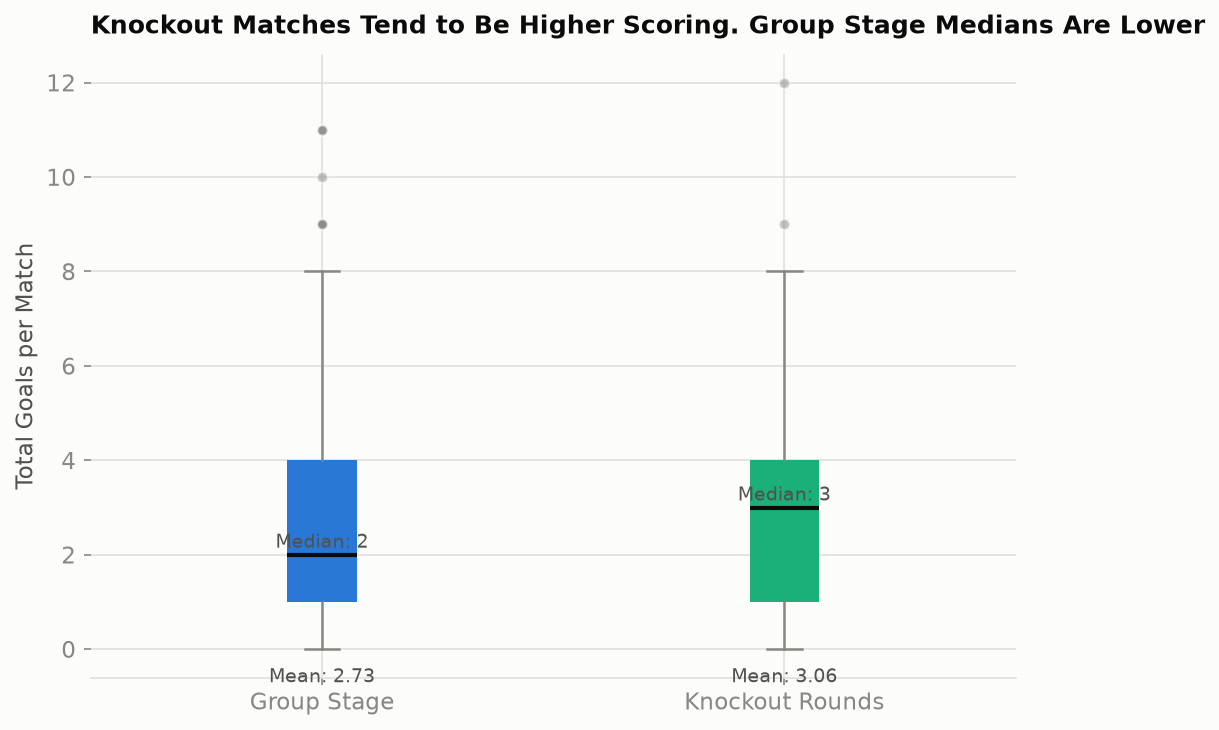

Group Stage: mean=2.73, median=2.0, n=696
Knockout Rounds: mean=3.06, median=3.0, n=268


In [15]:
#  Figure 6: Box plot — goals by stage 
wc_clean['stage_simple'] = wc_clean['stage'].apply(
    lambda s: 'Group Stage' if s == 'Group Stage' else 'Knockout Rounds'
)

fig, ax = plt.subplots(figsize=(7, 5))
stage_groups = [wc_clean.loc[wc_clean['stage_simple'] == s, 'total_goals'].values
                for s in ['Group Stage', 'Knockout Rounds']]

bp = ax.boxplot(stage_groups, patch_artist=True,
                medianprops=dict(color=INK, linewidth=2),
                boxprops=dict(linewidth=0),
                whiskerprops=dict(color=MUTED, linewidth=1.2),
                capprops=dict(color=MUTED, linewidth=1.2),
                flierprops=dict(marker='o', markerfacecolor=MUTED,
                                markeredgecolor=SURFACE, markersize=5, alpha=0.5))

bp['boxes'][0].set_facecolor(C1)
bp['boxes'][1].set_facecolor(C2)

ax.set_xticklabels(['Group Stage', 'Knockout Rounds'])
ax.set_title('Knockout Matches Tend to Be Higher Scoring. Group Stage Medians Are Lower',
             loc='left')
ax.set_ylabel('Total Goals per Match')
ax.yaxis.grid(True, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[['top','right','left']].set_visible(False)

for i, grp in enumerate(stage_groups):
    med = np.median(grp)
    mn  = np.mean(grp)
    ax.text(i + 1, med + 0.15, f'Median: {med:.0f}',
            ha='center', fontsize=9, color=INK_SEC)
    ax.text(i + 1, -0.7, f'Mean: {mn:.2f}',
            ha='center', fontsize=9, color=INK_SEC)

plt.tight_layout()
plt.savefig('fig6_goals_by_stage_box.png')
plt.show()

for s in ['Group Stage', 'Knockout Rounds']:
    d = wc_clean.loc[wc_clean['stage_simple'] == s, 'total_goals']
    print(f'{s}: mean={d.mean():.2f}, median={d.median():.1f}, n={len(d)}')


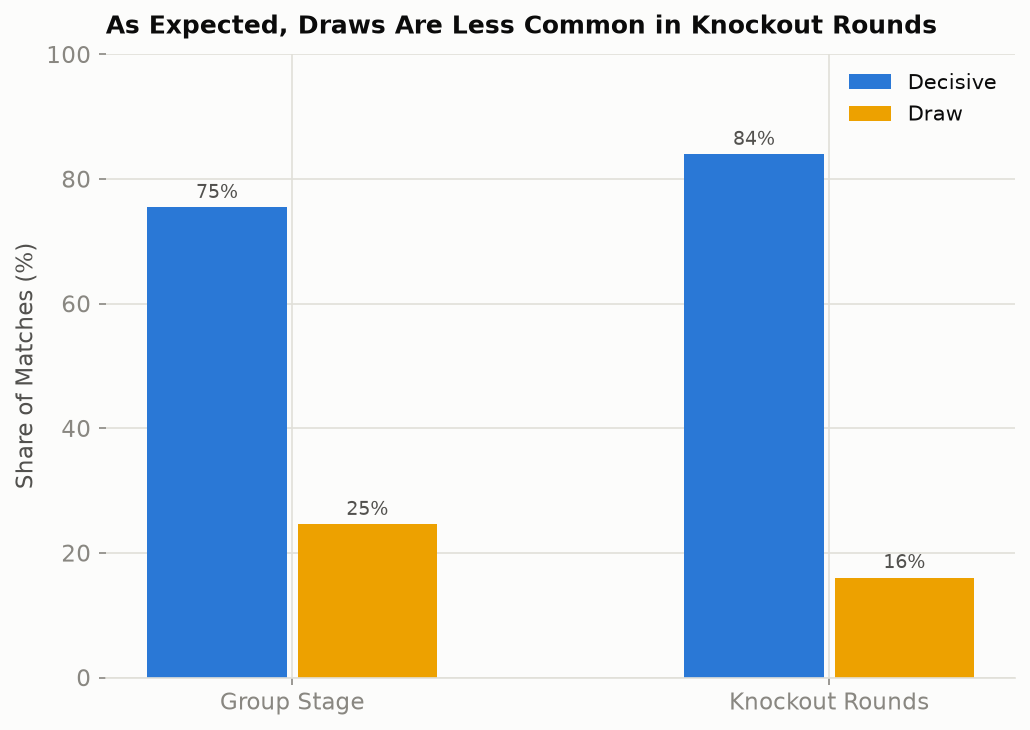

Figure 7 saved.
outcome          Decisive  Draw
stage_simple                   
Group Stage          75.4  24.6
Knockout Rounds      84.0  16.0


In [16]:
#  Figure 7: Outcome distribution — Group Stage vs Knockout 
stage_outcome = (wc_clean.groupby(['stage_simple','outcome'])
                          .size()
                          .unstack(fill_value=0))
stage_outcome_pct = stage_outcome.div(stage_outcome.sum(axis=1), axis=0) * 100
stage_outcome_pct = stage_outcome_pct.reindex(['Group Stage', 'Knockout Rounds'])

outcome_cols = ['Decisive', 'Draw']
oc_colors    = [C1, C3]
x = np.arange(len(stage_outcome_pct))
width = 0.28

fig, ax = plt.subplots(figsize=(7, 5))
for i, (col, clr) in enumerate(zip(outcome_cols, oc_colors)):
    vals = stage_outcome_pct[col].values if col in stage_outcome_pct.columns else np.zeros(2)
    bars = ax.bar(x + (i - 0.5) * width, vals,
                  width=width - 0.02, color=clr, linewidth=0, label=col)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2,
                b.get_height() + 0.8,
                f'{v:.0f}%', ha='center', va='bottom',
                fontsize=9, color=INK_SEC)

ax.set_xticks(x)
ax.set_xticklabels(['Group Stage', 'Knockout Rounds'])
ax.set_title('As Expected, Draws Are Less Common in Knockout Rounds',
             loc='left')
ax.set_ylabel('Share of Matches (%)')
ax.set_ylim(0, 100)
ax.yaxis.grid(True, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[['top','right','left']].set_visible(False)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('fig7_outcome_by_stage.png')
plt.show()
print('Figure 7 saved.')
print(stage_outcome_pct.round(1))


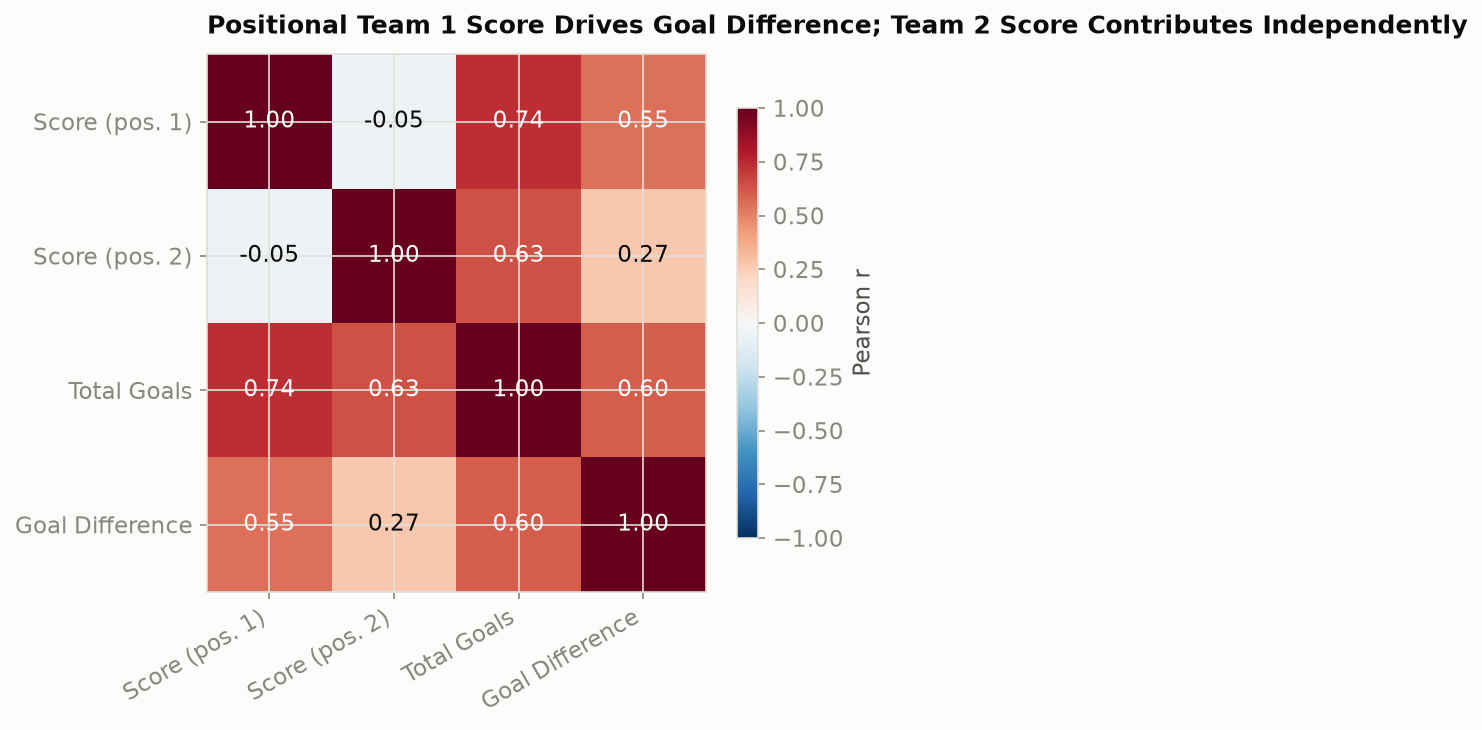

Figure 8 saved.


In [17]:
#  Figure 8: Correlation heatmap 
numeric_cols = ['home_score', 'away_score', 'total_goals', 'goal_diff']
corr = wc_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))

cmap = plt.cm.RdBu_r
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}',
                ha='center', va='center',
                fontsize=11, color='white' if abs(corr.iloc[i,j]) > 0.5 else INK)

labels = ['Score (pos. 1)', 'Score (pos. 2)', 'Total Goals', 'Goal Difference']
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_yticklabels(labels)
ax.set_title('Positional Team 1 Score Drives Goal Difference; Team 2 Score Contributes Independently',
             loc='left')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
plt.tight_layout()
plt.savefig('fig8_correlation_heatmap.png')
plt.show()
print('Figure 8 saved.')


### 4.4 RQ3: Host-Nation Advantage

For RQ3, a per tournament bar chart shows the host nation win rate for each of the 23 tournament entries from 1930 to 2022. Each bar is colour coded green (win rate above 50%) or red (below 50%), with a reference line at 50% to indicate what a team would achieve by chance in a decisive or draw tournament. This lets the reader compare individual tournaments and spot whether the home advantage signal has changed across eras.


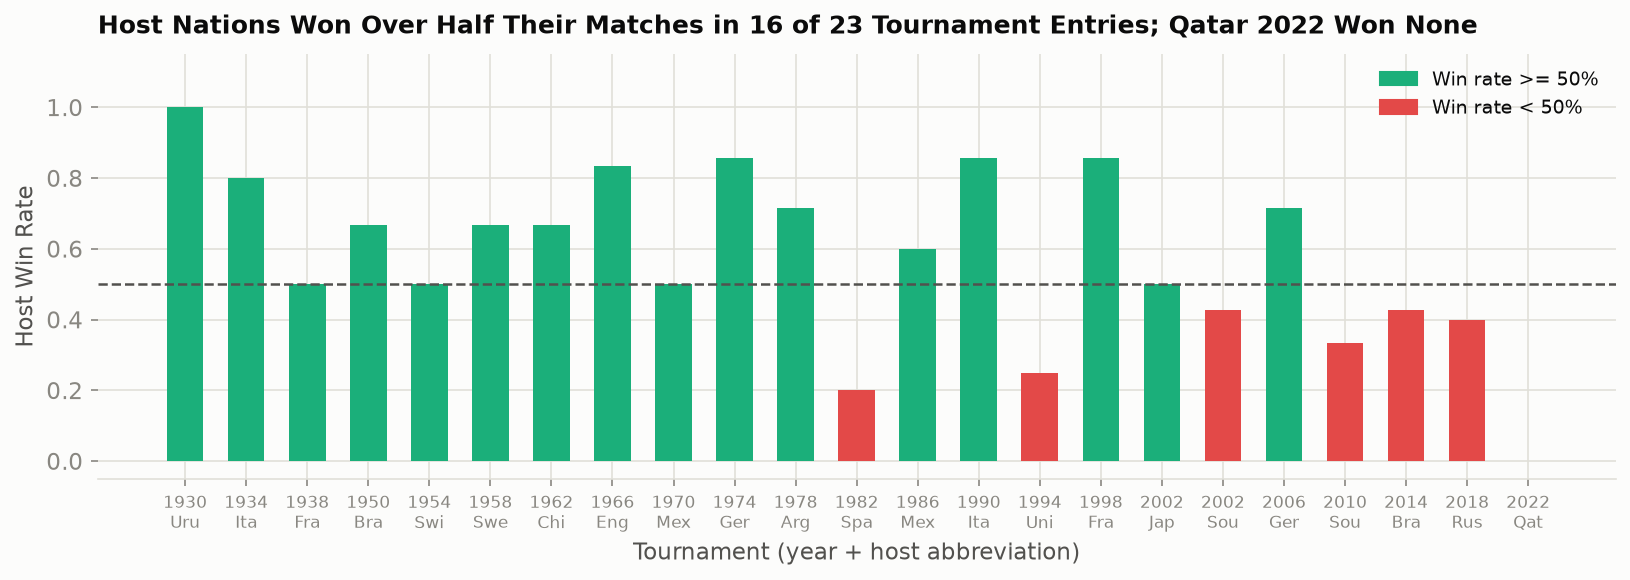

Figure 9 saved.
Overall host win rate: 61.2%
 year     host_team  win_rate  matches
 1930       Uruguay  1.000000        4
 1934         Italy  0.800000        5
 1938        France  0.500000        2
 1950        Brazil  0.666667        6
 1954   Switzerland  0.500000        4
 1958        Sweden  0.666667        6
 1962         Chile  0.666667        6
 1966       England  0.833333        6
 1970        Mexico  0.500000        4
 1974       Germany  0.857143        7
 1978     Argentina  0.714286        7
 1982         Spain  0.200000        5
 1986        Mexico  0.600000        5
 1990         Italy  0.857143        7
 1994 United States  0.250000        4
 1998        France  0.857143        7
 2002         Japan  0.500000        4
 2002   South Korea  0.428571        7
 2006       Germany  0.714286        7
 2010  South Africa  0.333333        3
 2014        Brazil  0.428571        7
 2018        Russia  0.400000        5
 2022         Qatar  0.000000        3


In [18]:
#  Figure 9: Host win rate per tournament
# Build host match records (previously in separate cell)
host_records = []
for _, row in wc_clean.iterrows():
    h = row['host_nation']
    host_teams = ['South Korea', 'Japan'] if h == 'Korea/Japan' else [h]
    for ht in host_teams:
        if row['home_team'] == ht:
            host_records.append({
                'year': row['year'], 'host_team': ht,
                'gd': row['home_score'] - row['away_score'],
                'won': 1 if row['home_score'] > row['away_score'] else 0,
            })
        elif row['away_team'] == ht:
            host_records.append({
                'year': row['year'], 'host_team': ht,
                'gd': row['away_score'] - row['home_score'],
                'won': 1 if row['away_score'] > row['home_score'] else 0,
            })

host_df = pd.DataFrame(host_records)

host_by_year = host_df.groupby(['year','host_team']).agg(
    win_rate = ('won', 'mean'),
    matches  = ('won', 'count'),
    mean_gd  = ('gd', 'mean')
).reset_index()

above50 = (host_by_year['win_rate'] >= 0.5).sum()
total_entries = len(host_by_year)

fig, ax = plt.subplots(figsize=(11, 4))

x = range(len(host_by_year))
bar_colors = [C2 if w >= 0.5 else C6 for w in host_by_year['win_rate']]
bars = ax.bar(x, host_by_year['win_rate'], color=bar_colors, width=0.6, linewidth=0)

ax.axhline(0.5, color=INK_SEC, linewidth=1.2, linestyle='--')

xlabels = [f"{row['year']}\n{row['host_team'][:3]}" for _, row in host_by_year.iterrows()]
ax.set_xticks(list(x))
ax.set_xticklabels(xlabels, fontsize=8)
ax.set_title(f'Host Nations Won Over Half Their Matches in {above50} of {total_entries} Tournament Entries; Qatar 2022 Won None',
             loc='left')
ax.set_xlabel('Tournament (year + host abbreviation)')
ax.set_ylabel('Host Win Rate')
ax.set_ylim(-0.05, 1.15)
ax.yaxis.grid(True, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[['top','right','left']].set_visible(False)

patch_win  = mpatches.Patch(color=C2, label='Win rate >= 50%')
patch_loss = mpatches.Patch(color=C6, label='Win rate < 50%')
ax.legend(handles=[patch_win, patch_loss], frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('fig9_host_winrate.png')
plt.show()
print('Figure 9 saved.')
print(f'Overall host win rate: {host_df["won"].mean():.1%}')
print(host_by_year[['year','host_team','win_rate','matches']].to_string(index=False))


## 5. Interpretation and Discussion of Findings

### 5.1 RQ1: Goal Scoring Evolution (1930-2022)

The analysis reveals a structural shift in World Cup scoring across three eras. The pre modern period (1930-1966) saw high scoring, often volatile matches. The 1954 Switzerland tournament produced the highest average (5.4 goals per match), a peak partly attributable to the absence of substitutions, limited tactical development, and a pool of teams with highly unequal ability levels (Pollard & Reep, 1997). The 1970-1990 expansion era saw average goals decline toward 2.7-3.0 per match as tactics professionalised and the competitive gap between footballing nations narrowed. The modern era (1994-2022) has stabilised around 2.4-2.6 goals per match, consistent with findings by Lago-Peñas et al. (2010) that top level international football has converged toward an equilibrium of defensive organisation and controlled attacking play.

The stacked bar chart (Figure 5) shows that the draw rate rose sharply from the pre modern era (14%) to the expansion era (25%) and has remained elevated in the modern era (24%). The rise in draws from the 1960s onwards is consistent with the narrowing of ability gaps between nations. Fewer matches were decided by large margins, and draws became a more common result.

### 5.2 RQ2: Group Stage vs Knockout Dynamics

The box plot (Figure 6) shows that knockout matches are higher scoring than group stage matches on both median (3 vs 2) and mean (3.06 vs 2.73). The data suggests that once teams must win to advance, open, higher scoring matches result.

The grouped bar chart (Figure 7) reveals that draws are less frequent in knockout rounds (approximately 16% vs 25% in the group stage). These 16% are not undecided matches, they are games level at full time that went to extra time and remained level which the dataset records as the score and were ultimately settled by penalty shootout. The draw rate drop reflects the tournament structure. Penalties force a result where the full time plus extra time could not.

### 5.3 RQ3: Host Nation Advantage

The data supports the host nation advantage hypothesis. Across 22 tournaments, host nations won more than half their matches in 16 of 23 tournament entries (Figure 9), with an overall win rate of 61%. In a neutral venue tournament where a 50% win rate is the baseline, winning 61% of matches across 22 editions represents a consistent and meaningful advantage. The per tournament chart shows this advantage was strongest in the earlier eras (Uruguay 1930 (100%), Italy 1934 (80%), England 1966 (83%)) and has become less reliable in recent tournaments.

This finding aligns with Pollard's (2006) broader analysis of home advantage in football, attributing the effect to crowd support, reduced travel fatigue, and familiarity with local conditions. The exceptions (notably Russia 2018 and Qatar 2022, where host nations underperformed) may reflect the growing strength parity of the modern era identified in RQ1, making the structural advantage harder to leverage.

### 5.4 Limitations

Several limitations apply. First, the dataset is observational, so no causal inference is possible about the mechanisms behind any observed trend. Second, early tournaments (1930-1954) had small and unrepresentative participant pools, which inflates variance in per tournament statistics. Third, the stage derivation method is based on chronological ordering within each year, accurate for modern tournaments but an approximation for the 1974 and 1978 second group round format. Fourth, the 50% win rate baseline used for RQ3 is a simplification, it assumes all opponents are equally matched, which is not the case. Fifth, the dataset records scores at full time including extra time, knockout draws therefore represent matches settled by penalty shootout, not genuinely undecided results.


## 6. References and AI Declaration

### 6.1 References

Alamar, B. (2013). *Sports Analytics: A Guide for Coaches, Managers, and Other Decision Makers*. Columbia University Press.

Colomer, C. M., Pyne, D. B., Morin, J. B., & Cross, M. (2021). Performance analysis in rugby union: A critical systematic review. *Sports Medicine - Open*, 7(1), 1–15.

FIFA. (2023). *FIFA World Cup Qatar 2022 - Global broadcast and audience summary*. Fédération Internationale de Football Association.

Lago-Peñas, C., Lago-Ballesteros, J., Dellal, A., & Gómez, M. (2010). Game-related statistics that discriminated winning, drawing and losing teams from the Spanish soccer league. *Journal of Sports Science and Medicine*, 9(2), 288–293.

Martj42. (2024). *International Football Results from 1872 to 2024* [Dataset]. Kaggle. https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017

Pappalardo, L., Cintia, P., Rossi, A., Massucco, E., Ferragina, P., Pedreschi, D., & Giannotti, F. (2019). A public data set of spatio-temporal match events in soccer competitions. *Scientific Data*, 6(1), 236.

Pollard, R. (2006). Home advantage in soccer: Variations in its magnitude and a literature review of the inter-related factors associated with its existence. *Journal of Sport Behavior*, 29(2), 169–189.

Pollard, R., & Reep, C. (1997). Measuring the effectiveness of playing strategies at soccer. *Journal of the Royal Statistical Society: Series D (The Statistician)*, 46(4), 541–550.

Qin, X., Luo, Y., Tang, N., et al. (2020). Making data visualization more efficient and effective: a survey. *The VLDB Journal*, 29, 93–117. https://doi.org/10.1007/s00778-019-00588-3

Kelleher, C., & Wagener, T. (2011). Ten guidelines for effective data visualization in scientific publications. *Environmental Modelling & Software*, 26(6), 822–827.

---

### 6.2 AI Declaration

ChatGPT was used to assist in this coursework. It was used to create boilerplate and template code for the charts. This was then edited and refined manually. It was also used for debugging code. 

Research ideas, questions, analysis and conclusions are mine. ChatGPT was used to source references supporting the research ideas and questions.


## 7. Dashboard

The dashboard below provides a summary of the key findings from all three research questions. It is designed for a sports journalist audience: clear explanatory titles, consistent colour coding, and minimal technical decoration. Each panel addresses one key performance indicator identified in the analysis.

The dashboard is built in Plotly and is interactive within the Jupyter notebook (hover for exact values). When exported to PDF for submission, it renders as a static figure.


In [19]:
#  Dashboard: 2x3 Plotly subplot grid 
from plotly.subplots import make_subplots
import plotly.graph_objects as go

P_BLUE   = '#2a78d6'
P_AQUA   = '#1baf7a'
P_YELLOW = '#eda100'
P_RED    = '#e34948'
P_MUTED  = '#898781'
P_GRID   = '#e1e0d9'
P_INK    = '#0b0b0b'
P_BG     = '#fcfcfb'
P_SEC    = '#52514e'

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        'Goals Per Match by Year (RQ1)',
        'Decisive vs Draw by Era (RQ1)',
        'Goals by Stage: Group vs Knockout (RQ2)',
        'Draw Rate: Group Stage vs Knockout (RQ2)',
        'Host Nation Win Rate per Tournament (RQ3)',
        'Overall Host Win Rate vs 50% Baseline (RQ3)',
    ],
    vertical_spacing=0.16,
    horizontal_spacing=0.10,
)

# Panel 1: goals per match line
fig.add_trace(go.Scatter(
    x=yearly['year'], y=yearly['avg_goals'].round(2),
    mode='lines+markers',
    line=dict(color=P_BLUE, width=2),
    marker=dict(size=7, color=P_BLUE, line=dict(color='white', width=1.5)),
    hovertemplate='%{x}: %{y:.2f} goals/match<extra></extra>',
    name='Avg goals/match',
    showlegend=False,
), row=1, col=1)

# Panel 2: stacked bar — Decisive vs Draw by era
era_short = ['Pre-modern<br>1930-66', 'Expansion<br>1970-90', 'Modern<br>1994-22']
legend_shown = set()
for col_name, clr in [('Decisive', P_BLUE), ('Draw', P_YELLOW)]:
    vals = era_outcome_pct[col_name].values if col_name in era_outcome_pct.columns else [0, 0, 0]
    show = col_name not in legend_shown
    if show:
        legend_shown.add(col_name)
    fig.add_trace(go.Bar(
        x=era_short, y=vals.round(1),
        name=col_name,
        marker_color=clr,
        hovertemplate='%{x}<br>' + col_name + ': %{y:.1f}%<extra></extra>',
        showlegend=show,
        legendgroup=col_name,
    ), row=1, col=2)

# Panel 3: box plots — goals by stage
for stage_name, clr in [('Group Stage', P_BLUE), ('Knockout Rounds', P_AQUA)]:
    d = wc_clean.loc[wc_clean['stage_simple'] == stage_name, 'total_goals']
    fig.add_trace(go.Box(
        y=d, name=stage_name,
        marker_color=clr,
        line_color=clr,
        hovertemplate=stage_name + '<br>%{y} goals<extra></extra>',
        showlegend=False,
    ), row=1, col=3)

# Panel 4: draw rate bar
draw_rates = stage_outcome_pct['Draw'] if 'Draw' in stage_outcome_pct.columns else pd.Series([0, 0])
fig.add_trace(go.Bar(
    x=['Group Stage', 'Knockout Rounds'],
    y=draw_rates.values.round(1),
    marker_color=[P_YELLOW, P_MUTED],
    text=[f'{v:.0f}%' for v in draw_rates.values],
    textposition='outside',
    hovertemplate='%{x}: %{y:.1f}% draws<extra></extra>',
    showlegend=False,
), row=2, col=1)

# Panel 5: host win rate per tournament
fig.add_trace(go.Bar(
    x=host_by_year['year'].astype(str),
    y=(host_by_year['win_rate'] * 100).round(1),
    marker_color=[P_AQUA if w >= 0.5 else P_RED for w in host_by_year['win_rate']],
    hovertemplate='%{x}: %{y:.1f}% win rate<extra></extra>',
    showlegend=False,
), row=2, col=2)
fig.add_hline(y=50, line_dash='dash', line_color=P_SEC, line_width=1.2, row=2, col=2)

# Panel 6: overall host win rate vs 50% baseline
overall_wr = host_df['won'].mean() * 100
fig.add_trace(go.Bar(
    x=['Host Nations', '50% Baseline'],
    y=[round(overall_wr, 1), 50],
    marker_color=[P_AQUA, P_MUTED],
    text=[f'{overall_wr:.1f}%', '50.0%'],
    textposition='outside',
    hovertemplate='%{x}: %{y:.1f}%<extra></extra>',
    showlegend=False,
), row=2, col=3)

fig.update_layout(
    title=dict(
        text='<b>FIFA World Cup 1930-2022: Key Performance Indicators</b>'
             '<br><sup>RQ1: Scoring trends | RQ2: Stage dynamics | RQ3: Host advantage</sup>',
        font=dict(size=15, color=P_INK),
        x=0.03,
    ),
    height=780,
    width=1100,
    paper_bgcolor=P_BG,
    plot_bgcolor=P_BG,
    font=dict(family='system-ui, -apple-system, sans-serif', color=P_INK, size=11),
    barmode='stack',
    legend=dict(
        orientation='h', y=-0.06, x=0.25,
        font=dict(size=10), traceorder='normal',
        title=dict(text='Outcome:  ', font=dict(size=10)),
    ),
    margin=dict(t=100, b=80, l=50, r=30),
)

for i in range(1, 3):
    for j in range(1, 4):
        fig.update_xaxes(showgrid=False, linecolor=P_GRID, row=i, col=j)
        fig.update_yaxes(gridcolor=P_GRID, gridwidth=0.8, linecolor=P_GRID, row=i, col=j)

fig.update_xaxes(tickangle=45, row=2, col=2)

fig.update_yaxes(title_text='Avg goals/match', row=1, col=1)
fig.update_yaxes(title_text='Share (%)',        row=1, col=2)
fig.update_yaxes(title_text='Total goals',      row=1, col=3)
fig.update_yaxes(title_text='Draw rate (%)',    row=2, col=1)
fig.update_yaxes(title_text='Win rate (%)',     row=2, col=2)
fig.update_yaxes(title_text='Win rate (%)',     row=2, col=3)

fig.show()
print('Dashboard rendered.')


Dashboard rendered.


In [20]:
#  Export dashboard as static image for PDF embedding 
try:
    fig.write_image('fig_dashboard.png', width=1100, height=780, scale=2)
    print('Dashboard saved to fig_dashboard.png')
except Exception as e:
    print(f'Static export failed (kaleido may need install): {e}')


Dashboard saved to fig_dashboard.png
